# GECCO LBA — experiments & minimal figures

Interactive runs of **NSGA-II** on **input-routing genomes** (Holton-style `trial_df`, cyclic **A-B** schedule).

**Setup:** install the package once from the `gecco` folder (`pip install -e .`) and start Jupyter with the **kernel’s working directory** set to the **`gecco`** directory (same folder as `pyproject.toml`), so `import gecco` works.

Alternatively keep any cwd and extend `sys.path` in the next cell.

In [1]:
# Optional: if imports fail, uncomment and set GECCO_INSTALL to the folder that contains pyproject.toml
# import sys
# GECCO_INSTALL = "/path/to/Structure-Function-Analysis-of-Network-Topologies/gecco"
# if GECCO_INSTALL not in sys.path:
#     sys.path.insert(0, GECCO_INSTALL)

%matplotlib inline

from __future__ import annotations

import os
from pathlib import Path
from typing import Dict, List, Tuple

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from gecco.data.holton_trials import load_trial_df, pick_participants
from gecco.evolve.nsga2 import run_nsga2
from gecco.experiments.run_lba_figure import aggregate_cyclic_tensors, pareto_indices
from gecco.models.routing_rnn import (
    DualRouteRNN,
    SingleRouteRNN,
    routing_separation_score,
)
from gecco.experiments.run_lba_figure import _default_trial_df
from gecco.training.episode import apply_init_scale, train_on_schedule

## 1. Paths & hyperparameters

In [2]:
TRIAL_DF = Path(os.environ.get("GECCO_TRIAL_DF", str(_default_trial_df()))).expanduser()
_cwd = Path.cwd()
if (_cwd / "pyproject.toml").is_file():
    _gecco_root = _cwd
elif (_cwd.parent / "pyproject.toml").is_file():
    _gecco_root = _cwd.parent
else:
    _gecco_root = _cwd
FIG_DIR = (_gecco_root / "figures").resolve()
FIG_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "conditions": ["near", "far"],
    "participants_per_condition": 2,
    "max_trials_per_segment": 24,
    "cyclic_pattern": "ABABAB",
    "population": 24,
    "generations": 12,
    "train_steps": 80,
    "batch_size": 32,
    "lr": 0.02,
    "hidden": 32,
    "init_scale": 0.1,
    "baseline_init_low": 0.001,
    "baseline_init_high": 2.0,
    "seed": 0,
    "use_cpu": False,
}

device = torch.device("cuda" if torch.cuda.is_available() and not CONFIG["use_cpu"] else "cpu")
print("trial_df:", TRIAL_DF)
print("exists:", TRIAL_DF.is_file())
print("device:", device)
print("figures ->", FIG_DIR)

trial_df: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/transfer-interference/data/participants/trial_df.csv
exists: True
device: cuda
figures -> /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/gecco/figures


## 2. Load `trial_df` (preview)

In [3]:
if not TRIAL_DF.is_file():
    raise FileNotFoundError(f"Missing {TRIAL_DF} — set GECCO_TRIAL_DF or preprocess transfer-interference data.")

df = load_trial_df(str(TRIAL_DF))
display(df.head(3))
print("participants:", df["participant"].nunique(), "| conditions:", df["condition"].dropna().unique().tolist())

,participant,index,task_section,feature_idx,stimID,taskID,feat_val,noisy_feedback_value,resp_reactiontime,dial_resp,...,block,regime,accuracy,study,A_rule,B_rule,rule_applied,test_stim_B,test_stim_A,test_trial
0,study1_same_sub9,0,A1,0.0,2.0,0.0,0.900836,0.910773,12.212,4.886953,...,0,study1_same,0.268820,1,-1.901668,-1.901668,NaN,5.0,9.0,0
1,study1_same_sub9,1,A1,1.0,2.0,0.0,5.282353,5.264300,8.746,3.202714,...,0,study1_same,0.338030,1,-1.901668,-1.901668,2.291941,5.0,9.0,0
2,study1_same_sub9,2,A1,0.0,0.0,0.0,5.849861,5.946899,10.087,3.227958,...,0,study1_same,0.165422,1,-1.901668,-1.901668,NaN,5.0,9.0,0


participants: 305 | conditions: ['same', 'near', 'far']


## 3. Run NSGA-II per condition

Stores final **population**, **Pareto front**, and **single-module baselines** in `results`.

In [4]:
def make_evaluate(tensors: Dict[str, torch.Tensor], cfg: dict):
    def evaluate(genome: List[int]) -> Tuple[float, float]:
        m = DualRouteRNN(genome, hidden_per_module=cfg["hidden"])
        apply_init_scale(m, cfg["init_scale"])
        _, val = train_on_schedule(
            m,
            tensors,
            steps=cfg["train_steps"],
            lr=cfg["lr"],
            batch_size=cfg["batch_size"],
            device=device,
            seed=cfg["seed"] + (hash(tuple(genome)) % 997),
        )
        sep = routing_separation_score(genome)
        return val, -sep

    return evaluate


def run_baselines(tensors: Dict[str, torch.Tensor], cfg: dict) -> List[Tuple[str, float, str]]:
    rows = []
    for sigma, tag in [(cfg["baseline_init_low"], "low σ"), (cfg["baseline_init_high"], "high σ")]:
        sm = SingleRouteRNN(hidden_per_module=cfg["hidden"])
        apply_init_scale(sm, sigma)
        _, val = train_on_schedule(
            sm,
            tensors,
            steps=cfg["train_steps"] * 2,
            lr=cfg["lr"],
            batch_size=cfg["batch_size"],
            device=device,
            seed=cfg["seed"],
        )
        rows.append((tag, val))
    return rows


results: Dict[str, dict] = {}
for condition in CONFIG["conditions"]:
    pids = pick_participants(
        df,
        conditions=[condition],
        per_condition=CONFIG["participants_per_condition"],
        seed=CONFIG["seed"],
    )
    print(f"{condition}: participants {pids}")
    tensors = aggregate_cyclic_tensors(
        df.loc[df["participant"].isin(pids)],
        pids,
        max_trials_per_segment=CONFIG["max_trials_per_segment"],
        pattern=CONFIG["cyclic_pattern"],
        seed=CONFIG["seed"],
    )
    evaluate = make_evaluate(tensors, CONFIG)
    pop = run_nsga2(
        evaluate,
        genome_length=12,
        population_size=CONFIG["population"],
        generations=CONFIG["generations"],
        seed=CONFIG["seed"] + hash(condition) % 10000,
    )
    front = pareto_indices(pop)
    baselines = run_baselines(tensors, CONFIG)
    results[condition] = {
        "population": pop,
        "pareto": front,
        "baselines": baselines,
        "participants": pids,
    }
    print(f"  Pareto size: {len(front)} | final pop: {len(pop)}")

print("done.")

near: participants ['study1_near_sub1', 'study1_near_sub28']
  Pareto size: 5 | final pop: 24
far: participants ['study2_far_sub55', 'study2_far_sub6']
  Pareto size: 6 | final pop: 24
done.


## 4. Figure A — Pareto + single-module baselines

Same layout as `python -m gecco.experiments.run_lba_figure`.

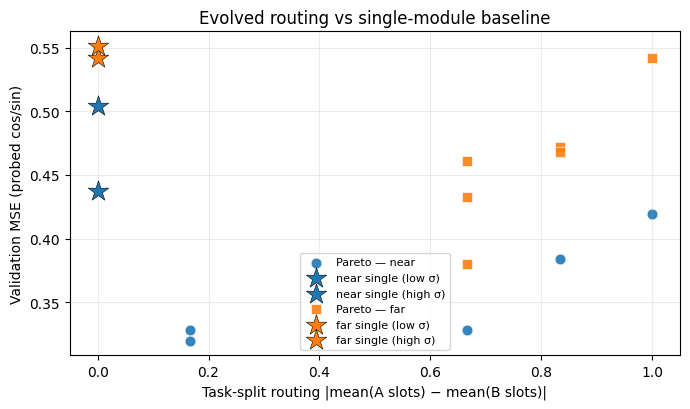

saved /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/gecco/figures/nb_lba_pareto.png


In [5]:
colors = {"near": "#1f77b4", "far": "#ff7f0e", "same": "#2ca02c"}
markers = {"near": "o", "far": "s", "same": "D"}

fig, ax = plt.subplots(figsize=(7, 4.2))
for condition, res in results.items():
    front = res["pareto"]
    xs = [routing_separation_score(ind.genome) for ind in front]
    ys = [ind.f1 for ind in front]
    ax.scatter(
        xs,
        ys,
        c=colors.get(condition, "gray"),
        marker=markers.get(condition, "o"),
        s=60,
        alpha=0.9,
        edgecolors="white",
        linewidths=0.5,
        label=f"Pareto — {condition}",
    )
    for tag, val in res["baselines"]:
        ax.scatter(
            [0.0],
            [val],
            marker="*",
            s=240,
            c=colors.get(condition, "gray"),
            edgecolors="black",
            linewidths=0.4,
            zorder=5,
            label=f"{condition} single ({tag})",
        )

ax.set_xlabel("Task-split routing |mean(A slots) − mean(B slots)|")
ax.set_ylabel("Validation MSE (probed cos/sin)")
ax.set_title("Evolved routing vs single-module baseline")
ax.legend(loc="best", fontsize=8)
ax.grid(True, alpha=0.25)
fig.tight_layout()
out_a = FIG_DIR / "nb_lba_pareto.png"
fig.savefig(out_a, dpi=160)
plt.show()
print("saved", out_a.resolve())

## 5. Figure B — Final population (MSE distribution)

Shows spread of validation MSE after evolution (all individuals, not only Pareto).

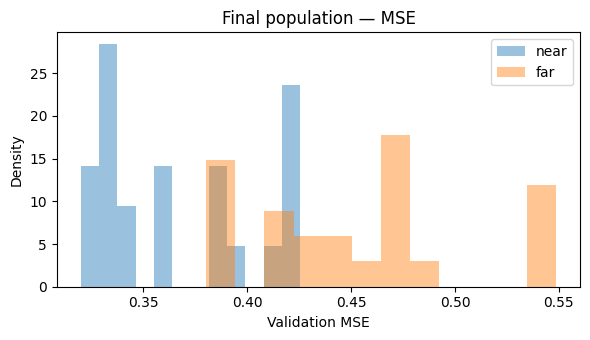

saved /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/gecco/figures/nb_lba_mse_hist.png


In [6]:
fig, ax = plt.subplots(figsize=(6, 3.5))
for condition, res in results.items():
    mses = [ind.f1 for ind in res["population"]]
    ax.hist(
        mses,
        bins=12,
        alpha=0.45,
        color=colors.get(condition, "gray"),
        label=condition,
        density=True,
    )
ax.set_xlabel("Validation MSE")
ax.set_ylabel("Density")
ax.set_title("Final population — MSE")
ax.legend()
fig.tight_layout()
out_b = FIG_DIR / "nb_lba_mse_hist.png"
fig.savefig(out_b, dpi=160)
plt.show()
print("saved", out_b.resolve())

## 6. Table — Pareto genomes (first condition only)

Expand / duplicate the loop if you want both conditions exported to CSV.

In [7]:
cond = CONFIG["conditions"][0]
rows = []
for ind in results[cond]["pareto"]:
    rows.append(
        {
            "condition": cond,
            "mse": ind.f1,
            "neg_sep_obj": ind.f2,
            "routing_separation": routing_separation_score(ind.genome),
            "genome": "".join(str(b) for b in ind.genome),
        }
    )
pareto_df = pd.DataFrame(rows).sort_values("mse")
display(pareto_df)
csv_path = FIG_DIR / f"nb_pareto_{cond}.csv"
pareto_df.to_csv(csv_path, index=False)
print("saved", csv_path.resolve())

,condition,mse,neg_sep_obj,routing_separation,genome
4,near,0.319845,-0.166667,0.166667,011111110110
3,near,0.327891,-0.166667,0.166667,001111110100
2,near,0.328408,-0.666667,0.666667,011011000000
1,near,0.384162,-0.833333,0.833333,111011000000
0,near,0.419259,-1.000000,1.000000,111111000000


saved /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/gecco/figures/nb_pareto_near.csv
